In [1]:
import numpy as np
import pandas as pd
import os
import random
import re


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import scipy.stats as stats
from functools import *

import Bio
from Bio import Entrez
from Bio import SeqIO
from Bio import Seq
from Bio.SeqUtils import GC
from Bio.SeqFeature import SeqFeature, FeatureLocation


sns.set_context("paper")
%matplotlib inline
sns.set_palette('Paired')


In [2]:
# Subsample the shorter ORFs

#this file contains info about ALL orfs that are annotated, have evidence from ribosome profiling data, or are ATG/CTG ORFs that are not truncated versions of longer ORFs
filtered = pd.read_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/virushostdb/orf_files/refseq_all_filtered1.csv')
print(len(filtered))
filtered.head()



182289


/opt/jupyterhub/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3203: DtypeWarning: Columns (17) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,virus_name,accession,description,virus_tax_id,genome_type,type,matpro_id,ann,location,product,...,length_aa,start_codon,strand,polypep?,length_nt,record_id,record_descript,start,end,stranded
0,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[143933:143939](+),rORF151,...,1,ACG,+,False,6.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[143933:143939](+)__1aa,143933,143939,True
1,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[4727:4733](-),rORF4,...,1,ATG,-,False,6.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[4727:4733](-)__1aa,4727,4733,True
2,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[72970:72979](+),rORF84,...,2,ATG,+,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[72970:72979](+)__2aa,72970,72979,True
3,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[52526:52535](-),rORF69,...,2,ATA,-,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[52526:52535](-)__2aa,52526,52535,True
4,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[177500:177509](-),rORF186,...,2,ATG,-,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[177500:177509](-)__2aa,177500,177509,True


/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density e

(0.0, 120.0)

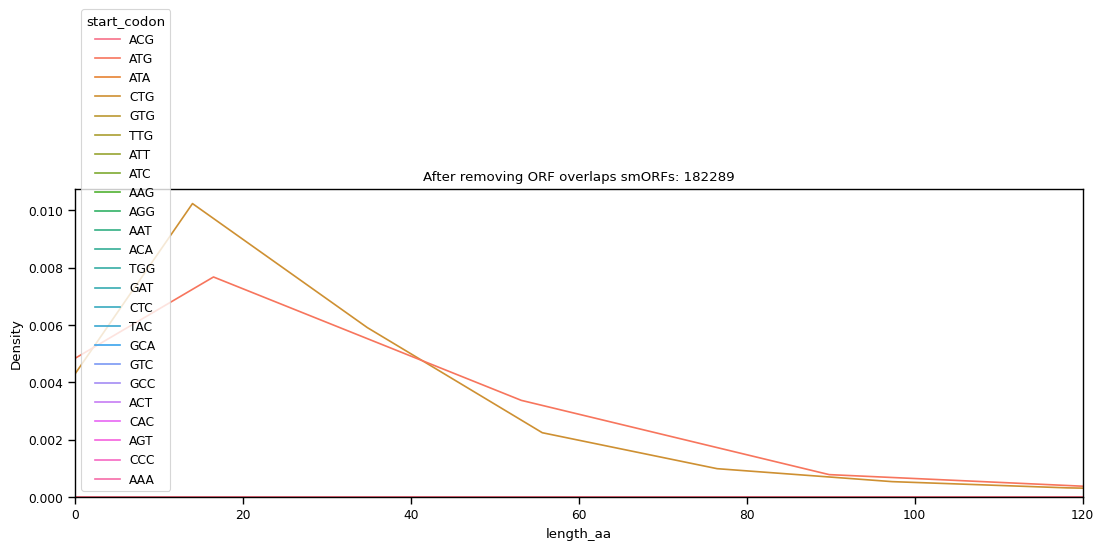

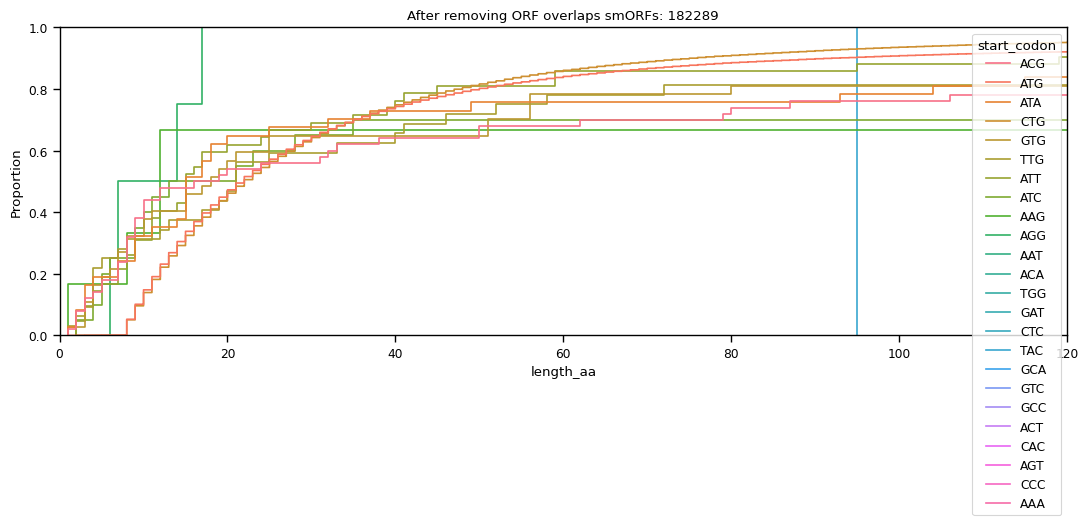

In [3]:
plt.figure(figsize=(13,4))
sns.kdeplot(data = filtered , x = 'length_aa', hue = 'start_codon')
plt.title(f'After removing ORF overlaps smORFs: {filtered.seq_aa.nunique()}')
plt.xlim(0,120)

plt.figure(figsize=(13,4))
sns.ecdfplot(data = filtered , x = 'length_aa', hue = 'start_codon')
plt.title(f'After removing ORF overlaps smORFs: {filtered.seq_aa.nunique()}')
plt.xlim(0,120)

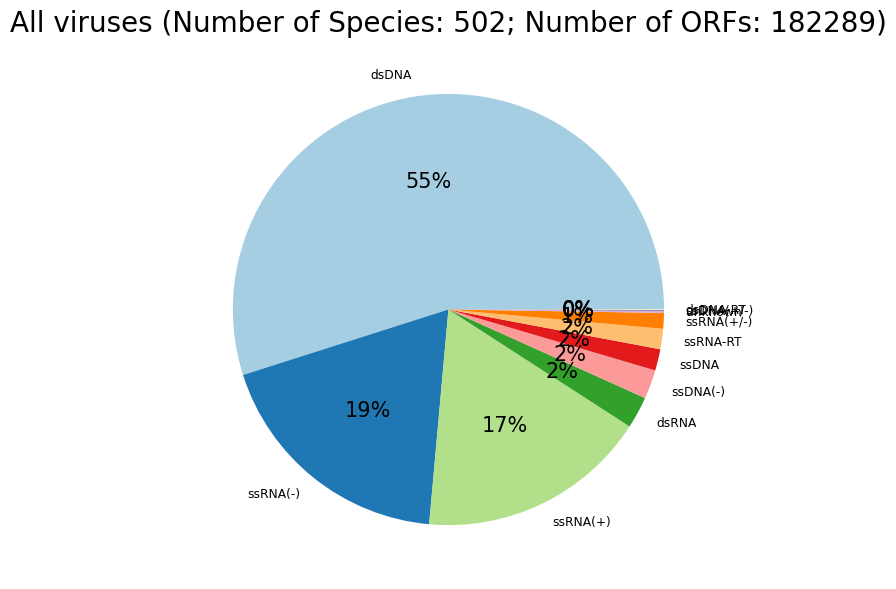

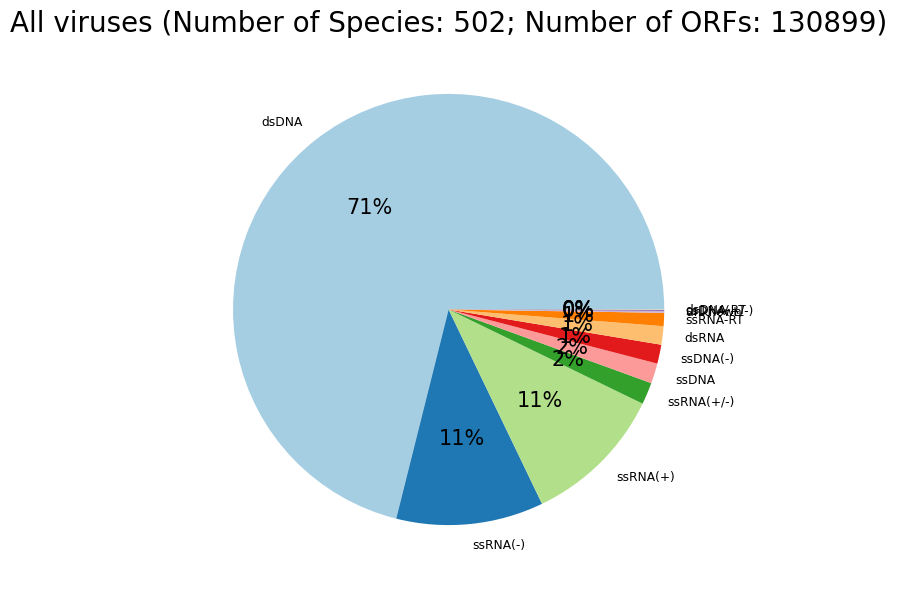

In [4]:
plt.figure(figsize=(15,7))
plt.rcParams['font.size'] = 15

sublist = filtered['genome_type']
plt.pie(sublist.value_counts().values, labels=sublist.value_counts().index, 
        autopct='%.0f%%')
plt.title(f'All viruses (Number of Species: {filtered.virus_tax_id.nunique()}; Number of ORFs: {filtered.seq_aa.nunique()})',
          fontsize = 20)
plt.show()

plt.figure(figsize=(15,7))
plt.rcParams['font.size'] = 15
sublist = filtered[filtered.stranded]['genome_type']
plt.pie(sublist.value_counts().values, labels=sublist.value_counts().index, 
        autopct='%.0f%%')
plt.title(f'All viruses (Number of Species: {filtered[filtered.stranded].virus_tax_id.nunique()}; Number of ORFs: {filtered[filtered.stranded].seq_aa.nunique()})',
          fontsize = 20)
plt.show()

# Subsample on short annotated things

In [5]:
min_len = 25
num_subsamp = 0.75

#take all the things I should definitely include
yes_strand = filtered[filtered.stranded]
print(len(yes_strand))
no_strand = filtered[~filtered.stranded]
print(len(no_strand))

print(len(filtered))
filtered = filtered[filtered.stranded]



riboseq = yes_strand[yes_strand.matpro_id =='ribo-seq']
annotated = yes_strand[(yes_strand.matpro_id !='ribo-seq') & (yes_strand.matpro_id !='Unannotated')]
translated = yes_strand[yes_strand.matpro_id !='Unannotated']


unannotated = yes_strand[yes_strand.matpro_id=='Unannotated']
long_unan_ATG = unannotated[(unannotated.length_aa >= min_len) & (unannotated.start_codon == 'ATG')]
long_unan_CTG = unannotated[(unannotated.length_aa >= min_len) & (unannotated.start_codon == 'CTG')]


#subsample on the shorter things
short_unan_ATG = unannotated[(unannotated.length_aa < min_len) & (unannotated.start_codon == 'ATG')].reset_index(drop=True)
short_unan_CTG = unannotated[(unannotated.length_aa < min_len) & (unannotated.start_codon == 'CTG')].reset_index(drop=True)

np.random.seed(seed=100)
randint = np.random.choice(list(range(len(short_unan_ATG)+1)), size = int(len(short_unan_ATG)*num_subsamp), replace =False)
sub_ATG = short_unan_ATG.iloc[randint-1]

np.random.seed(seed=200)
randint = np.random.choice(list(range(len(short_unan_CTG)+1)), size = int(len(short_unan_CTG)*num_subsamp), replace =False)
sub_CTG = short_unan_CTG.iloc[randint-1]


print(len(translated))
print(len(long_unan_ATG))
print(len(long_unan_CTG))
print(len(short_unan_ATG))
print(len(short_unan_CTG))
print('')
print(len(sub_ATG))
print(len(sub_CTG))
print('')

#merge to compile 
dfs = [translated, long_unan_ATG, long_unan_CTG, sub_ATG, sub_CTG]
print(len(dfs))


130899
51390
182289
7846
25949
27140
39178
30786

29383
23089

5


# If I didn't subsample and only picked out things that have homology to other stuff, let's see if they appear any differed


In [6]:
all_align = pd.read_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/homology/vORF_ALL_raw_resultDB.m8'
                     , sep = "\t+|;| ", header = None, 
                     names = ['record_id', 'match', 'percent_identity',
                              'align_len', 'num_mm', 'num_gap', 'start1', 'end1', 
                              'start2', 'end2', 'E-value','bit_score', ''],
                     engine='python')

In [7]:
df1s = [annotated, riboseq, long_unan_ATG, long_unan_CTG, sub_ATG, sub_CTG]
label = ['annotated', 'riboseq', 'long_unan_ATG', 'long_unan_CTG', 'sub_ATG', 'sub_CTG']
for i,df in enumerate(df1s):
    print(label[i])
    
    print(f'Number of sequences in subpool: {len(df)}')
    num = len(all_align[all_align.record_id.isin(df.record_id)].drop_duplicates('record_id'))
    print(f'Number of sequences found to align to Uniprot: {num}')
    
    #if len(df) - num <50:
        #display(df[~df.record_id.isin(all_align.record_id)])
        #print(len(align.merge(df, on ='record_id').drop_duplicates('record_id')))
    
    if num<50:
        align = all_align[all_align.record_id.isin(df.record_id)].drop_duplicates('record_id')
        #print(len(align.merge(df, on ='record_id').drop_duplicates('record_id')))
        #display(align.merge(df, on ='record_id').drop_duplicates('record_id'))
    
    print(f'Number of sequences that do not align to Uniprot: {len(df[~df.record_id.isin(all_align.record_id)])}')
    print('')
    


annotated
Number of sequences in subpool: 7105
Number of sequences found to align to Uniprot: 6967
Number of sequences that do not align to Uniprot: 138

riboseq
Number of sequences in subpool: 741
Number of sequences found to align to Uniprot: 192
Number of sequences that do not align to Uniprot: 549

long_unan_ATG
Number of sequences in subpool: 25949
Number of sequences found to align to Uniprot: 3615
Number of sequences that do not align to Uniprot: 22334

long_unan_CTG
Number of sequences in subpool: 27140
Number of sequences found to align to Uniprot: 3277
Number of sequences that do not align to Uniprot: 23863

sub_ATG
Number of sequences in subpool: 29383
Number of sequences found to align to Uniprot: 466
Number of sequences that do not align to Uniprot: 28917

sub_CTG
Number of sequences in subpool: 23089
Number of sequences found to align to Uniprot: 375
Number of sequences that do not align to Uniprot: 22714



# Generate controls for each subpool


Query Length \
Substitution Matrix \
Gap Costs \
<35	PAM-30	(9,1) \
35-50	PAM-70	(10,1) \
50-85	BLOSUM-80	(10,1) \
85	BLOSUM-62	(10,1)


In [8]:
#now that a shuffled sequence is generated, check if sequence is similar to anything else available
          
def shuffle_nt(seq):
    
    i = 0
    shuf = True
    #process nucleotide sequence 
    #make sure there's at least one stop codon
    if seq[-3:] in ['TAA','TAG', 'TGA']:
        seq = seq[:-3]
    else:
        seq = seq + 'TAG'
        
    #make sure there's no start codon
    if seq[0:3] in ['ATG', 'CTG']:
        seq = seq[3:]
        
    while shuf:
        
        #shuffle nucleotide sequence
        np.random.seed(seed=i)
        s = list(seq)
        np.random.shuffle(s)
        s=''.join(s)

        #translate to amino acid sequence
        aa = Seq.Seq(s).translate()

        #if sequence only has one STOP codon, then take the nucleotide but put the stop codon at the end
        if sum(list(np.array(list(aa))=='*'))==1:

            stop_ind = int(np.where(np.array(list(aa))=='*')[0]*3)
            shuf_seq = 'ATG' + s[0:stop_ind]  + s[stop_ind+3:] + s[stop_ind:stop_ind+3]
            shuf_aa = Seq.Seq(shuf_seq).translate()
            
            seq_aa = str(shuf_aa[0:-1])
            #print('Sequence found!')
            break

        else:
            shuf = True
            i+=1
            #print('stop detected, continue shuffling')
            
        if i >100:
            shuf_seq = ''
            seq_aa = ''
            break
            
    return shuf_seq, seq_aa


def shuffle_aa(seq, seed = 100):
    
    ###process nucleotide sequence 
    #make sure there's no stop codon
    if seq[-3:] in ['TAA','TAG', 'TGA']:
        seq = seq[:-3]

    #make sure there's no start codon
    if seq[0:3] in ['ATG', 'CTG']:
        seq = seq[3:]
    #print(seq)

    #shuffle amino acid sequence
    np.random.seed(seed=seed)
    s = list(range(int(len(seq)/3)))
    np.random.shuffle(s)
    # print(Seq.Seq('ATG'+seq).translate())
    # print(pd.Series(Seq.Seq('ATG'+seq).translate()).value_counts())

    shuf_seq = [str(seq[(i*3):(i*3+3)]) for i in s]
    shuf_seq = 'ATG' + ''.join(shuf_seq)
    seq_aa = str(Seq.Seq(shuf_seq).translate())
    # print(Seq.Seq(seq_shuf).translate())
    # print(pd.Series(Seq.Seq(seq_shuf).translate()).value_counts())
            
    return shuf_seq, seq_aa






In [9]:
#generate shuffled sequences as control
percent_rand = 0.03

dfs_rand=[]
label=['translated', 'unannotated_long_ATG', 'unannotated_long_CTG', 'ATG_subsample', 'CTG_subsample']

##############shuffle by nucleotide sequence
percent_rand1 = 0.02
for i,df in enumerate(dfs):
    
    df['Subpool'] = [label[i]]*len(df)
    
    
    ##############add in ORFs of shuffled nt and aa sequences
    print(label[i])
    #randomly pick percent_rand of sequences in library and shuffle nucleotide sequence
    #remove ones with stop codons
    np.random.seed(seed=i)
    numpick = int(len(df)*(1+percent_rand) - len(df))
    randint = np.random.randint(low = 0, high = len(df), size = numpick)
    randint.sort()
    sub_rand = df.iloc[randint].reset_index(drop=True)
    
    
    #shuffle nucleotide sequences
    #divide up by lengths so substitution matrix doesn't have to be loaded every time
    shufs_nt = [shuffle_nt(s) for s in sub_rand.seq_nt]
    shufs = np.array(shufs_nt)
    
    #shuffle amino acid sequences
    #divide up by lengths so substitution matrix doesn't have to be loaded every time
    shufs_aa = [shuffle_aa(s) for s in sub_rand.seq_nt]
    shufs = np.concatenate((shufs_nt, np.array(shufs_aa)), axis = 0)
    
    
    rand_df = pd.concat([sub_rand.copy(), sub_rand.copy()]).reset_index(drop=True)
    rand_df['seq_nt'] = shufs.T[0] 
    rand_df['seq_aa'] = shufs.T[1]

    rand_df['type'] = ['shuffled_nt']*len(shufs_nt) + ['shuffled_aa']*len(shufs_aa)
    rand_df['ann'] = [False]*len(rand_df)
    rand_df['location'] = ['shuffled']*len(rand_df)
    rand_df['product'] = ['shuffled_nt']*len(shufs_nt) + ['shuffled_aa']*len(shufs_aa)
    rand_df['note'] = ['shuffled'+ str(m) for m in rand_df.matpro_id]
    rand_df['matpro_id'] = rand_df.matpro_id
    rand_df['aa_match'] = [True]*len(rand_df)
    rand_df['start_codon'] = ['ATG']*len(rand_df)
    rand_df['record_id'] = ['shuffled_'+ m for m in rand_df.record_id]
    rand_df['record_descript'] = ['shuffled_'+ m for m in rand_df.record_descript]
    rand_df['length_aa'] = [len(aa) for aa in rand_df.seq_aa]
    rand_df['length_nt'] = [len(nt) for nt in rand_df.seq_nt]
    rand_df['Subpool'] = [label[i]]*len(rand_df)
    #remove things that are just ''
    rand_df = rand_df[rand_df.seq_aa != ''].reset_index(drop = True)
    rand_df = rand_df.drop_duplicates(subset=['seq_aa'], keep='first')
    
    
    ##############add in ORFs from other strand if genome does appear strand specific
    sub = no_strand[no_strand.accession.isin(df.accession) & (no_strand.length_aa <= max(df.length_aa )) & (no_strand.length_aa >= min(df.length_aa))].reset_index(drop = True)
    np.random.seed(seed=i)
    numpick = int(len(df)*(1+percent_rand1) - len(df))
    
    if len(sub) != 0:
        print(len(sub))
        randint = np.random.randint(low = 0, high = len(sub), size = numpick)
        other_ctrl = sub.iloc[randint]
        other_ctrl['type'] = ['antisense_strand']*len(other_ctrl) 
        other_ctrl['Subpool'] = [label[i]]*len(other_ctrl)
        merged = pd.concat([df,rand_df, other_ctrl]).drop_duplicates(subset = 'seq_aa', keep = 'first')
        
    else:
        merged = pd.concat([df,rand_df]).drop_duplicates(subset = 'seq_aa', keep = 'first')
    dfs_rand.append(merged.reset_index(drop=True))
    
dfs_random = pd.concat(dfs_rand).drop_duplicates(subset = 'seq_aa', keep = 'first').reset_index(drop=True)
dfs_random.head()



translated


/tmp/ipykernel_4050080/3091712706.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Subpool'] = [label[i]]*len(df)
/usr/local/lib/python3.8/dist-packages/Bio/Seq.py:2979: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


51390
unannotated_long_ATG


/tmp/ipykernel_4050080/3091712706.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_ctrl['type'] = ['antisense_strand']*len(other_ctrl)
/tmp/ipykernel_4050080/3091712706.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_ctrl['Subpool'] = [label[i]]*len(other_ctrl)
/tmp/ipykernel_4050080/3091712706.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

21798
unannotated_long_CTG


...

29274
CTG_subsample


/tmp/ipykernel_4050080/3091712706.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_ctrl['type'] = ['antisense_strand']*len(other_ctrl)
/tmp/ipykernel_4050080/3091712706.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_ctrl['Subpool'] = [label[i]]*len(other_ctrl)
/tmp/ipykernel_4050080/3091712706.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

29240


/tmp/ipykernel_4050080/3091712706.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_ctrl['type'] = ['antisense_strand']*len(other_ctrl)
/tmp/ipykernel_4050080/3091712706.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_ctrl['Subpool'] = [label[i]]*len(other_ctrl)


,virus_name,accession,description,virus_tax_id,genome_type,type,matpro_id,ann,location,product,...,start_codon,strand,polypep?,length_nt,record_id,record_descript,start,end,stranded,Subpool
0,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[143933:143939](+),rORF151,...,ACG,+,False,6.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[143933:143939](+)__1aa,143933,143939,True,translated
1,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[4727:4733](-),rORF4,...,ATG,-,False,6.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[4727:4733](-)__1aa,4727,4733,True,translated
2,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[72970:72979](+),rORF84,...,ATG,+,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[72970:72979](+)__2aa,72970,72979,True,translated
3,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[52526:52535](-),rORF69,...,ATA,-,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[52526:52535](-)__2aa,52526,52535,True,translated
4,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[177500:177509](-),rORF186,...,ATG,-,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[177500:177509](-)__2aa,177500,177509,True,translated


In [10]:
dfs_random.reset_index(drop=True).to_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/virushostdb/orf_files/refseq_all_filtered1_stranded_with_random.csv', index = None)
dfs_random[dfs_random.location != 'shuffled'].reset_index(drop=True).to_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/virushostdb/orf_files/refseq_all_filtered1_stranded_no_random.csv', index = None)

In [11]:
dfs_random=pd.read_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/virushostdb/orf_files/refseq_all_filtered1_stranded_with_random.csv')
dfs_random.head()

/opt/jupyterhub/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3203: DtypeWarning: Columns (17) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,virus_name,accession,description,virus_tax_id,genome_type,type,matpro_id,ann,location,product,...,start_codon,strand,polypep?,length_nt,record_id,record_descript,start,end,stranded,Subpool
0,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[143933:143939](+),rORF151,...,ACG,+,False,6.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[143933:143939](+)__1aa,143933,143939,True,translated
1,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[4727:4733](-),rORF4,...,ATG,-,False,6.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[4727:4733](-)__1aa,4727,4733,True,translated
2,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[72970:72979](+),rORF84,...,ATG,+,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[72970:72979](+)__2aa,72970,72979,True,translated
3,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[52526:52535](-),rORF69,...,ATA,-,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[52526:52535](-)__2aa,52526,52535,True,translated
4,Human betaherpesvirus 5,ribo-seq Human betaherpesvirus 5,"Human herpesvirus 5 strain Merlin, complete ge...",NaN,NaN,CDS,ribo-seq,True,[177500:177509](-),rORF186,...,ATG,-,False,9.0,ribo-seq-Human-betaherpesvirus-5__CDS__ribo-se...,Human betaherpesvirus 5__[177500:177509](-)__2aa,177500,177509,True,translated


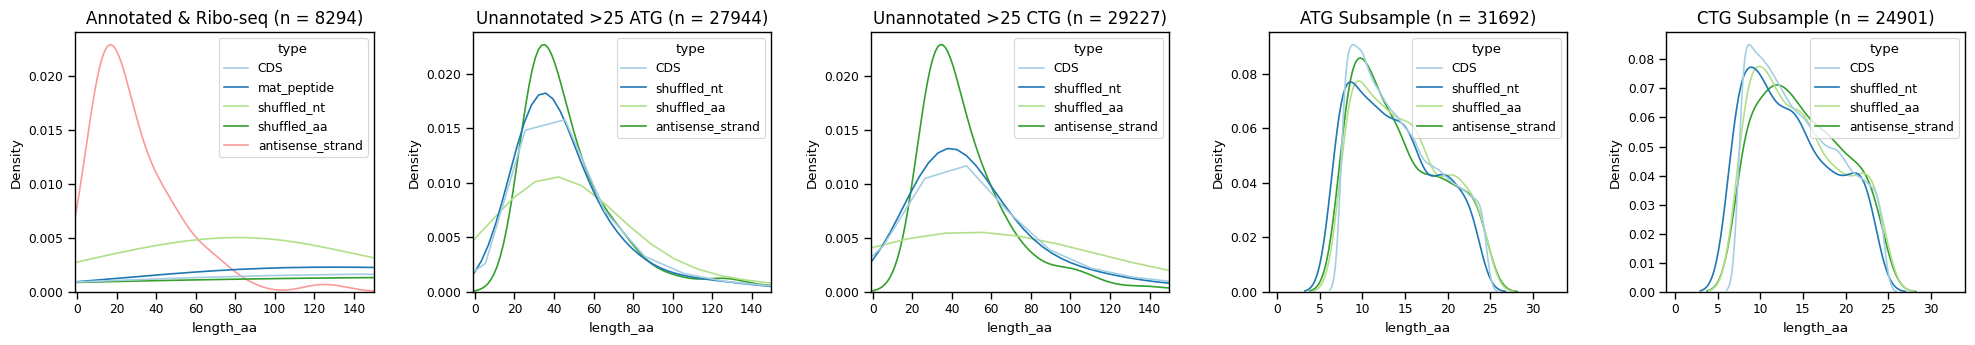

In [12]:
label=['Annotated & Ribo-seq', 'Unannotated >25 ATG', 'Unannotated >25 CTG', 'ATG Subsample', 'CTG Subsample']
plt.figure(figsize=(20,3.7))
for i,subpool in enumerate(dfs_random.Subpool.unique()):
    
    df = dfs_random[dfs_random.Subpool==subpool]
    plt.subplot(1,len(dfs_random.Subpool.unique()),i+1)
    plt.title(f"{label[i]} (n = {len(df)})")
    
    g = sns.kdeplot(data=df.reset_index(), x ='length_aa',hue = 'type', common_norm=False)
    plt.title(f"{label[i]} (n = {len(df)})", fontsize = 12)
    plt.xlim(-1,min((max(df.length_aa)+10, 150)))
    sns.move_legend(g, "upper right")


plt.tight_layout()
plt.show()
    

In [13]:
print(dfs_random.seq_aa.nunique())
len(dfs_random)

122058


122058

In [14]:
print(len(dfs_random[dfs_random.location != 'shuffled']))
dfs_random[dfs_random.location != 'shuffled'].seq_aa.nunique()

115616


115616

In [15]:
print(len(dfs_random[dfs_random.type == 'antisense_strand']))
print(len(dfs_random[dfs_random.location == 'shuffled']))
dfs_random[dfs_random.location == 'shuffled'].seq_aa.nunique()

2210
6442


6442

In [16]:
#make fasta file
#export as fasta file
records = []

for i in range(len(dfs_random[dfs_random.location == 'shuffled'].reset_index())):
    o = filtered.iloc[i]
    
    record = Bio.SeqRecord.SeqRecord(Seq.Seq(o['seq_aa']))
    record.id = f"{'-'.join(o['accession'].split(' '))}__{o['type']}__{o['matpro_id']}__{'-'.join(o['product'].split(' '))}"
    record.description = f"{o.virus_name}__{o.location}__{o.length_aa}aa"
    records.append(record)
    
    if i%1000==0:
        print(f"{i} sequences processed")
#     print(record.id)
#     print(record.description)
               

with open('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/homology/refseq_all_filtered1_stranded_RANDOM_ONLY.faa', "w") as output_handle:
     SeqIO.write(records, output_handle, "fasta")

0 sequences processed
1000 sequences processed
2000 sequences processed
3000 sequences processed
4000 sequences processed
5000 sequences processed
6000 sequences processed


In [17]:
#align random sequences with mmseq2
# #remove all sequences that cluster with anything else in database
# randalign = pd.read_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/homology/vORF_ALL_random/vORF_ALL_random_alignDB.m8'
#                      , sep = "\t+|;| ", header = None, 
#                      names = ['mmseq_cluster', 'record_id', 'percent_identity',
#                               'align_len', 'num_mm', 'num_gap', 'start1', 'end1', 
#                               'start2', 'end2', 'E-value','bit_score'],
#                      engine='python')

# randsearch = pd.read_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/homology/vORF_ALL_random/vORF_ALL_random_resultDB.m8'
#                      , sep = "\t+|;| ", header = None, 
#                      names = ['mmseq_cluster', 'record_id', 'percent_identity',
#                               'align_len', 'num_mm', 'num_gap', 'start1', 'end1', 
#                               'start2', 'end2', 'E-value','bit_score'],
#                      engine='python')
# display(randalign)
# display(randsearch)

In [18]:
#looks like nothing in my controls look similar to stuff in my filtered library dataset
# dfs_random.reset_index(drop=True).to_csv('/lab/solexa_weissman/yhc/viral_smORF/data_analysis/virushostdb/orf_files/refseq_all_subsample_ctrls.csv', index = None)

In [19]:
##different tags?
##fluor tags?
##FLAG
##HA
##Linkers
##NLS
##V5 tag
##epitope tag
##avian oncogenic viruses
##bpv oncogenic proteins
##v-myc causative gene in chicken viruses
##